In [18]:
import pandas as pd
import numpy as np

import seaborn as sns
sns.set_theme(palette="colorblind")

# Load data

In [9]:
df = pd.read_csv("advertising.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [ ]:
# train-test split

from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(df, test_size=0.2, 
                                       random_state=7, shuffle=False)

In [11]:
train_set.shape, test_set.shape

((160, 4), (40, 4))

# EDA

<Axes: >

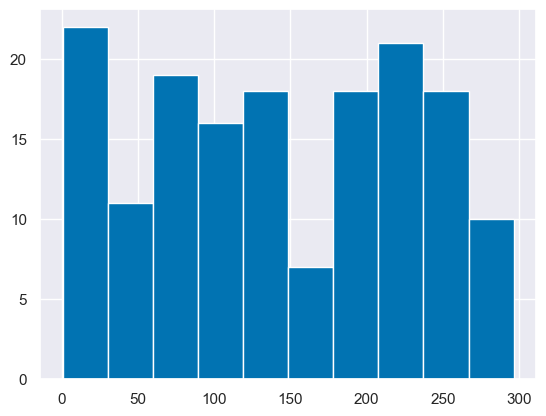

In [28]:
train_set["TV"].hist()

<Axes: >

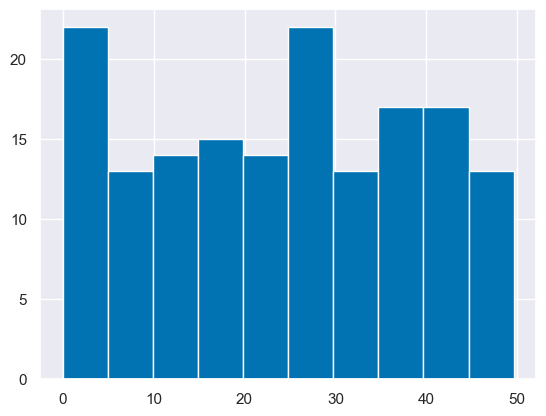

In [15]:
train_set["radio"].hist()

<Axes: >

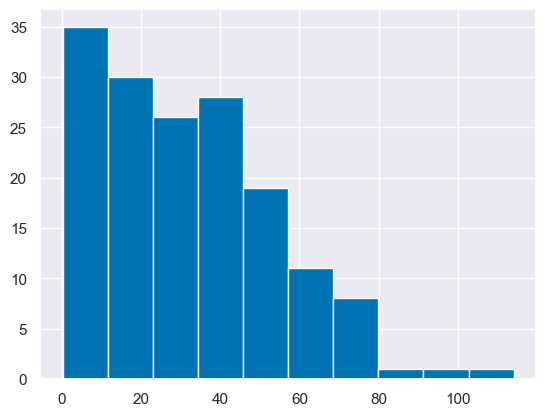

In [16]:
train_set["newspaper"].hist()

<Axes: >

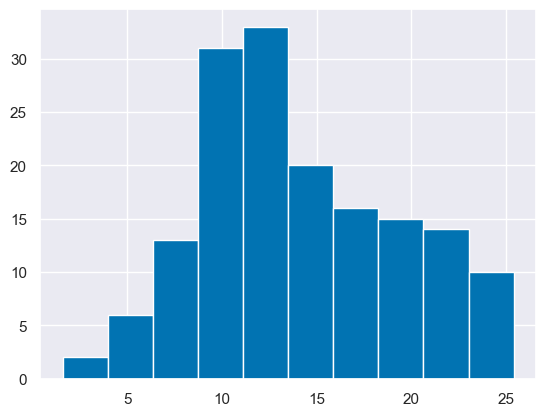

In [17]:
train_set["sales"].hist()

In [19]:
train_set.corr()

,TV,radio,newspaper,sales
TV,1.000000,0.054803,0.026687,0.801892
radio,0.054803,1.000000,0.373335,0.546288
newspaper,0.026687,0.373335,1.000000,0.205343
sales,0.801892,0.546288,0.205343,1.000000


# Model training

In [ ]:
from sklearn.metrics import root_mean_squared_error

X_train = train_set.drop("sales", axis=1)
y_train = train_set["sales"]

X_test = test_set.drop("sales", axis=1)
y_test = test_set["sales"]

In [24]:
# baseline

from sklearn.dummy import DummyRegressor

baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)

yhat_baseline = baseline.predict(X_train)
rmse_baseline = root_mean_squared_error(y_train, yhat_baseline)
rmse_baseline

5.212716984392592

In [29]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV


model = DecisionTreeRegressor(random_state=7)

hp_grid = {
    "max_depth": [2, 3, 4, 5, 6, 7, 8, 9, 10],
    "min_samples_leaf": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
}

# HP tuning with GridSearchCV
grid_search = GridSearchCV(model, hp_grid, cv=5,
                           scoring="neg_root_mean_squared_error", return_train_score=True)
grid_search.fit(X_train, y_train)

,estimator,DecisionTreeR...andom_state=7)
,param_grid,"{'max_depth': [2, 3, ...], 'min_samples_leaf': [1, 2, ...]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,criterion,'squared_error'


In [30]:
cv_results = pd.DataFrame(grid_search.cv_results_)[['params', 'mean_train_score', 'mean_test_score']]
cv_results["mean_train_score"] = -cv_results["mean_train_score"]
cv_results["mean_test_score"] = -cv_results["mean_test_score"]
cv_results["diff, %"] = 100*(cv_results["mean_train_score"]-cv_results["mean_test_score"]
                                                     )/cv_results["mean_train_score"]

cv_results.sort_values('mean_test_score')

,params,mean_train_score,mean_test_score,"diff, %"
71,"{'max_depth': 9, 'min_samples_leaf': 2}",0.359106,1.105760,-207.920303
61,"{'max_depth': 8, 'min_samples_leaf': 2}",0.361604,1.117110,-208.932263
41,"{'max_depth': 6, 'min_samples_leaf': 2}",0.461046,1.133784,-145.915594
51,"{'max_depth': 7, 'min_samples_leaf': 2}",0.385934,1.140668,-195.560657
60,"{'max_depth': 8, 'min_samples_leaf': 1}",0.113792,1.141905,-903.498329
...,...,...,...,...
5,"{'max_depth': 2, 'min_samples_leaf': 6}",2.213393,2.492119,-12.592701
9,"{'max_depth': 2, 'min_samples_leaf': 10}",2.213393,2.492119,-12.592701
8,"{'max_depth': 2, 'min_samples_leaf': 9}",2.213393,2.492119,-12.592701
6,"{'max_depth': 2, 'min_samples_leaf': 7}",2.213393,2.492119,-12.592701


# Evaluate on test

In [25]:
# baseline
yhat = baseline.predict(X_test)
rmse_bl = root_mean_squared_error(y_test, yhat)
rmse_bl

5.171828776228482

In [26]:
# best decision tree model
yhat = grid_search.best_estimator_.predict(X_test)
rmse = root_mean_squared_error(y_test, yhat)
rmse

0.9162347467276669

In [32]:
# feature importances
feature_importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": grid_search.best_estimator_.feature_importances_
}).sort_values("importance", ascending=False)
feature_importances

,feature,importance
0,TV,0.663237
1,radio,0.334809
2,newspaper,0.001954
